In [1]:
!pip install optuna
!pip install catboost
!pip install fairlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 12.1 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split ,GroupShuffleSplit, cross_val_score,cross_val_predict, GroupKFold, StratifiedGroupKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline as Pipe
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.feature_selection import SelectFromModel
import optuna
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import VotingClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import average_precision_score, precision_recall_curve
from fairlearn.metrics import MetricFrame
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import numpy as np
import pandas as pd
from fairlearn.metrics import (
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference,
    equal_opportunity_difference
)
from fairlearn.reductions import ExponentiatedGradient, DemographicParity

In [3]:
df = pd.read_csv('preprocessing.csv')
df.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,change,diabetesMed,readmitted,medical_specialty_grouped,primary_diag,secondary_diag,additional_diag,med_change,num_med,service_utilization
0,2278392,8222157,1,0,1,5,18,1,1,41,...,0,0,0,Pediatrics,4,0,0,0,0,0
1,149190,55629189,1,0,2,1,1,7,3,59,...,1,1,0,Unknown,0,4,0,1,1,0
2,64410,86047875,2,0,3,1,1,7,2,11,...,0,1,0,Unknown,0,4,0,0,1,3
3,500364,82442376,1,1,4,1,1,7,2,44,...,1,1,0,Unknown,0,4,1,1,1,0
4,16680,42519267,1,1,5,1,1,7,1,51,...,1,1,0,Unknown,8,8,4,0,2,0


In [4]:
numeric_cols = [
    'number_diagnoses', 'num_lab_procedures', 'num_med', 'time_in_hospital',
    'med_change', 'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'service_utilization', 'num_procedures'
]

categorical_cols = [
     'race','admission_type_id', 'discharge_disposition_id', 'admission_source_id',
    'max_glu_serum', 'A1Cresult', 'medical_specialty_grouped', 'primary_diag'
]


In [5]:
# Features
X = df.drop(columns=['readmitted','encounter_id'])  # drop target + identifiers

# Target
y = df['readmitted']

race = X['race']

In [6]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=15)

train_idx, test_idx = next(gss.split(X, y, groups=X['patient_nbr']))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]
A_train = X_train["race"]
A_test = X_test["race"]

groups = X_train['patient_nbr']

In [7]:
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, val_idx = next(gss_val.split(X_train, y_train, groups=groups))

X_tr = X_train.iloc[train_idx]
X_val = X_train.iloc[val_idx]
y_tr = y_train.iloc[train_idx]
y_val = y_train.iloc[val_idx]

In [8]:
  import matplotlib.pyplot as plt

In [9]:
def evaluate_model(model):

    # Train
    model.fit(X_train.drop(columns=['patient_nbr']), y_train, sensitive_features=A_train)
    y_pred = model.predict(X_test)

    # Accuracy
    acc = balanced_accuracy_score(y_test, y_pred)
    print("Balanced Accuracy:", acc)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:\n", cm)

    # Classification report
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    # ROC-AUC
    if hasattr(model, "predict_proba"):
      y_proba = model.predict_proba(X_test)[:, 1]  # probability for positive class
      pr_auc = average_precision_score(y_test, y_proba)
      print("PR-AUC:", pr_auc)

# Confusion matrix helper (robust to missing classes)
    def safe_confusion(y_true, y_pred):
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        return tn, fp, fn, tp

    # Metric definitions
    def PPR(y_true, y_pred):
        return np.mean(y_pred == 1)

    def FPR(y_true, y_pred):
        tn, fp, fn, tp = safe_confusion(y_true, y_pred)
        return fp / (fp + tn) if (fp + tn) > 0 else 0

    def FNR(y_true, y_pred):
        tn, fp, fn, tp = safe_confusion(y_true, y_pred)
        return fn / (fn + tp) if (fn + tp) > 0 else 0

    metrics = {"PPR": PPR, "FPR": FPR, "FNR": FNR}

    sensitive_features_list = ['race', 'gender', 'age']

    all_results = {}

    for feature in sensitive_features_list:
        mf = MetricFrame(
          metrics=metrics,
          y_true=y_test,
          y_pred=y_pred,
          sensitive_features=X_test[feature]
           )

        results = mf.by_group.copy()

        print(f"\n=== Fairness Metrics by {feature} for {type(model).__name__} ===")
        print(results)

    metrics = {}

    for feature in ['race', 'gender', 'age']:
        sf = X_test[feature]

        metrics[feature] = {
          #"dp_diff": demographic_parity_difference(y_test, y_pred, sensitive_features=sf),
          "dp_ratio": demographic_parity_ratio(y_test, y_pred, sensitive_features=sf),
          "eo_diff": equalized_odds_difference(y_test, y_pred, sensitive_features=sf),
          "eop_diff": equal_opportunity_difference(y_test, y_pred, sensitive_features=sf),
        }


        df = pd.DataFrame(metrics).T
    print(df)

# Modeling

In [10]:

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)


## Decstion tree

In [ ]:
base_dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=15,
    class_weight='balanced'
)

### class weight

In [ ]:
pipe_dt = ImbPipeline([
    ('preprocessor', preprocessor),
    ('model', base_dt)
])

exponentiated_gradient = ExponentiatedGradient(
    estimator=pipe_dt,
    constraints=DemographicParity(),
    sample_weight_name="model__sample_weight",
)

evaluate_model(exponentiated_gradient)

Balanced Accuracy: 0.5993245791274764

Confusion Matrix:
 [[12582  5099]
 [ 1207  1146]]

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.71      0.80     17681
           1       0.18      0.49      0.27      2353

    accuracy                           0.69     20034
   macro avg       0.55      0.60      0.53     20034
weighted avg       0.83      0.69      0.74     20034


=== Fairness Metrics by race for ExponentiatedGradient ===
           PPR       FPR       FNR
race                              
1     0.307169  0.282554  0.513393
2     0.336207  0.315355  0.501149
3     0.282561  0.273171  0.627907
4     0.281250  0.232759  0.250000
5     0.316294  0.300353  0.533333
6     0.288840  0.274038  0.560976

=== Fairness Metrics by gender for ExponentiatedGradient ===
             PPR       FPR       FNR
gender                              
0       0.339788  0.316126  0.485714
1       0.278594  0.255811  0.546314

=== Fair

## XGboost

In [ ]:
base_xgb= XGBClassifier(
    colsample_bytree=1.0,
    learning_rate=0.001,
    max_depth=4,
    min_child_weight=1,
    n_estimators=1000,
    subsample=1.0,
    random_state=15,
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1]),
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1)

### Class weight

In [ ]:

pipe_xgb= ImbPipeline([
    ('preprocessor', preprocessor),
    ('model', base_xgb)
])


In [ ]:
exponentiated_gradient = ExponentiatedGradient(
    estimator=pipe_xgb,
    constraints=DemographicParity(),
    sample_weight_name="model__sample_weight",
)

evaluate_model(exponentiated_gradient)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:07:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:07:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:08:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:08:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Balanced Accuracy: 0.6129918778499628

Confusion Matrix:
 [[11322  6359]
 [  975  1378]]

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.64      0.76     17681
           1       0.18      0.59      0.27      2353

    accuracy                           0.63     20034
   macro avg       0.55      0.61      0.51     20034
weighted avg       0.83      0.63      0.70     20034


=== Fairness Metrics by race for ExponentiatedGradient ===
           PPR       FPR       FNR
race                              
1     0.388085  0.359642  0.404576
2     0.384274  0.362216  0.443678
3     0.362031  0.343902  0.465116
4     0.273438  0.224138  0.250000
5     0.399361  0.374558  0.366667
6     0.387309  0.382212  0.560976

=== Fairness Metrics by gender for ExponentiatedGradient ===
             PPR       FPR       FNR
gender                              
0       0.412356  0.385236  0.387645
1       0.355316  0.329603  0.447070

=== Fair

## lightgbm

In [11]:
from lightgbm import LGBMClassifier

scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

base_lgb = LGBMClassifier(
    colsample_bytree=0.8,      # fraction of features per tree
    learning_rate=0.03,        # step size
    max_depth=4,               # max depth of each tree
    min_child_weight=1,        # minimum sum of instance weights in a leaf (LGBM uses min_child_samples)
    n_estimators=400,          # number of boosting rounds
    subsample=0.8,             # fraction of rows per tree
    random_state=15,
    class_weight=None,          # will use scale_pos_weight manually
    scale_pos_weight=scale_pos_weight,  # same as XGBoost
    n_jobs=-1,
    verbose=-1
)

### class weight

In [12]:
pipe_lg= ImbPipeline([
    ('preprocessor', preprocessor),
    ('model', base_lgb)
])



exponentiated_gradient = ExponentiatedGradient(
    estimator=pipe_lg,
    constraints=DemographicParity(),
    sample_weight_name="model__sample_weight",
)

evaluate_model(exponentiated_gradient)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Balanced Accuracy: 0.6153528150937112

Confusion Matrix:
 [[11676  6005]
 [ 1011  1342]]

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.66      0.77     17681
           1       0.18      0.57      0.28      2353

    accuracy                           0.65     20034
   macro avg       0.55      0.62      0.52     20034
weighted avg       0.83      0.65      0.71     20034


=== Fairness Metrics by race for ExponentiatedGradient ===
           PPR       FPR       FNR
race                              
1     0.366543  0.337595  0.422433
2     0.372518  0.350133  0.452874
3     0.348786  0.326829  0.441860
4     0.343750  0.293103  0.166667
5     0.364217  0.339223  0.400000
6     0.350109  0.343750  0.585366

=== Fairness Metrics by gender for ExponentiatedGradient ===
             PPR       FPR       FNR
gender                              
0       0.388105  0.361466  0.415444
1       0.341495  0.313984  0.447070

=== Fair

## Random Forest

In [ ]:
base_rf= RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=15,
    class_weight='balanced'
)

### Class weight

In [ ]:
pipe_rf = ImbPipeline([
    ('preprocessor', preprocessor),
    ('model', base_rf)
])


exponentiated_gradient = ExponentiatedGradient(
    estimator=pipe_rf,
    constraints=DemographicParity(),
    sample_weight_name="model__sample_weight",
)

evaluate_model(exponentiated_gradient)


Balanced Accuracy: 0.6177219007113194

Confusion Matrix:
 [[12406  5275]
 [ 1097  1256]]

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.70      0.80     17681
           1       0.19      0.53      0.28      2353

    accuracy                           0.68     20034
   macro avg       0.56      0.62      0.54     20034
weighted avg       0.83      0.68      0.74     20034


=== Fairness Metrics by race for ExponentiatedGradient ===
           PPR       FPR       FNR
race                              
1     0.323258  0.293271  0.458147
2     0.338297  0.316239  0.489655
3     0.298013  0.270732  0.441860
4     0.328125  0.284483  0.250000
5     0.332268  0.307420  0.433333
6     0.334792  0.336538  0.682927

=== Fairness Metrics by gender for ExponentiatedGradient ===
             PPR       FPR       FNR
gender                              
0       0.350669  0.323560  0.449421
1       0.296877  0.268725  0.486767

=== Fair

## imblearn ensemble

In [ ]:
from sklearn.ensemble import BaggingClassifier
base_estimator = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=15
)

# Bagging model
base_bagging = BaggingClassifier(
    estimator=base_estimator,
    random_state=15
)

pipe_ba = ImbPipeline([
    ('preprocessor', preprocessor),
    ('model', base_bagging )
])

exponentiated_gradient = ExponentiatedGradient(
    estimator=pipe_ba,
    constraints=DemographicParity(),
    sample_weight_name="model__sample_weight",
)

evaluate_model(exponentiated_gradient)



Balanced Accuracy: 0.5093691276574485

Confusion Matrix:
 [[13098  4583]
 [ 1699   654]]

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.74      0.81     17681
           1       0.12      0.28      0.17      2353

    accuracy                           0.69     20034
   macro avg       0.51      0.51      0.49     20034
weighted avg       0.80      0.69      0.73     20034


=== Fairness Metrics by race for ExponentiatedGradient ===
           PPR       FPR       FNR
race                              
1     0.258297  0.256296  0.727121
2     0.262278  0.257589  0.701149
3     0.291391  0.292683  0.720930
4     0.296875  0.310345  0.833333
5     0.297125  0.296820  0.700000
6     0.291028  0.290865  0.707317

=== Fairness Metrics by gender for ExponentiatedGradient ===
             PPR       FPR       FNR
gender                              
0       0.264638  0.261466  0.711969
1       0.257591  0.256549  0.734405

=== Fair

In [13]:
eps_values = [0.01, 0.05, 0.1]

results = []

for eps in eps_values:
    expgrad = ExponentiatedGradient(
        estimator=pipe_lg,
        constraints=DemographicParity(),
        eps=eps,
        sample_weight_name="model__sample_weight",
    )

    expgrad.fit(X_train.drop(columns=['patient_nbr']), y_train, sensitive_features=A_train)
    y_pred = expgrad.predict(X_test)

    acc = balanced_accuracy_score(y_test, y_pred)
    dp = demographic_parity_difference(y_test, y_pred, sensitive_features=X_test['race'])

    results.append({
        "eps": eps,
        "balanced_accuracy": acc,
        "dp_diff": dp
    })

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

In [ ]:
df_tradeoff = pd.DataFrame(results)
print(df_tradeoff)

    eps  balanced_accuracy   dp_diff
0  0.01           0.615185  0.032957
1  0.05           0.621897  0.037552
2  0.10           0.614830  0.054740


In [14]:
pipe_lg.fit(X_train.drop(columns=['patient_nbr']), y_train)
y_pred_base = pipe_lg.predict(X_test)

baseline_acc = balanced_accuracy_score(y_test, y_pred_base)
baseline_dp = demographic_parity_difference(
    y_test, y_pred_base, sensitive_features=X_test['race']
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [15]:
pipe_lg= ImbPipeline([
    ('preprocessor', preprocessor),
    ('model', base_lgb)
])

pipe_lg.fit(X_train.drop(columns=['patient_nbr']), y_train)


exponentiated_gradient = ExponentiatedGradient(
    estimator=pipe_lg,
    constraints=DemographicParity(),
    sample_weight_name="model__sample_weight",
)
exponentiated_gradient.fit(X_train.drop(columns=['patient_nbr']), y_train, sensitive_features=A_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

ExponentiatedGradient(constraints=<fairlearn.reductions._moments.utility_parity.DemographicParity object at 0x79e1bbb955e0>,
                      estimator=Pipeline(steps=[('preprocessor',
                                                 ColumnTransformer(remainder='passthrough',
                                                                   transformers=[('num',
                                                                                  'passthrough',
                                                                                  ['number_diagnoses',
                                                                                   'num_lab_procedures',
                                                                                   'num_med',
                                                                                   'time_in_hospital',
                                                                                   'med_change',
                                                                                   'num_medications',
                                                                                   'number_o...
                                                                                   'max_glu_serum',
                                                                                   'A1Cresult',
                                                                                   'medical_specialty_grouped',
                                                                                   'primary_diag'])])),
                                                ('model',
                                                 LGBMClassifier(colsample_bytree=0.8,
                                                                learning_rate=0.03,
                                                                max_depth=4,
                                                                min_child_weight=1,
                                                                n_estimators=400,
                                                                n_jobs=-1,
                                                                random_state=15,
                                                                scale_pos_weight=7.893491781430475,
                                                                subsample=0.8,
                                                                verbose=-1))]),
                      nu=np.float64(0.0008449121756815914),
                      sample_weight_name='model__sample_weight')

In [ ]:
# BEFORE mitigation
y_predLG = pipe_lg.predict(X_test)
acc_lg = balanced_accuracy_score(y_test, y_predLG)
dp_lg = demographic_parity_difference(
    y_test,
    y_predLG,
    sensitive_features=X_test['race']
)

# AFTER mitigation
y_predEX = exponentiated_gradient.predict(X_test)
acc_exp = balanced_accuracy_score(y_test, y_predEX)
dp_exp = demographic_parity_difference(
    y_test,
    y_predEX,
    sensitive_features=X_test['race']
)

# BEFORE mitigation
scores_before = pipe_lg.predict_proba(
    X_test.drop(columns=['patient_nbr'])
)[:, 1]

# AFTER mitigation
scores_after = exponentiated_gradient._pmf_predict(
    X_test.drop(columns=['patient_nbr'])
)[:, 1]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

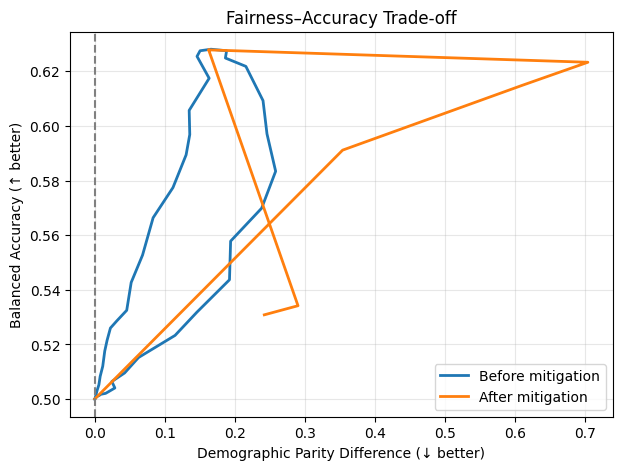

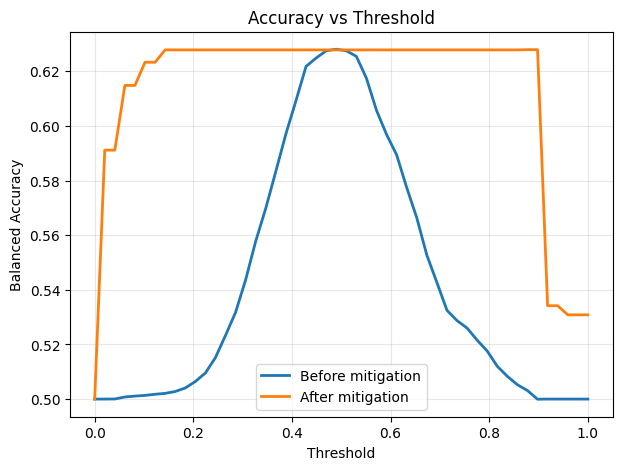

In [ ]:
import numpy as np
from sklearn.metrics import balanced_accuracy_score
from fairlearn.metrics import demographic_parity_difference

thresholds = np.linspace(0, 1, 50)

acc_before, dp_before = [], []
acc_after, dp_after = [], []

for t in thresholds:
    yb = (scores_before >= t).astype(int)
    ya = (scores_after >= t).astype(int)

    acc_before.append(balanced_accuracy_score(y_test, yb))
    acc_after.append(balanced_accuracy_score(y_test, ya))

    dp_before.append(abs(demographic_parity_difference(
        y_test, yb, sensitive_features=X_test['race']
    )))
    dp_after.append(abs(demographic_parity_difference(
        y_test, ya, sensitive_features=X_test['race']
    )))

    import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(dp_before, acc_before, label="Before mitigation", linewidth=2)
plt.plot(dp_after, acc_after, label="After mitigation", linewidth=2)

plt.axvline(0, linestyle="--", color="gray")

plt.xlabel("Demographic Parity Difference (↓ better)")
plt.ylabel("Balanced Accuracy (↑ better)")
plt.title("Fairness–Accuracy Trade-off")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(7,5))

plt.plot(thresholds, acc_before, label="Before mitigation", linewidth=2)
plt.plot(thresholds, acc_after, label="After mitigation", linewidth=2)

plt.xlabel("Threshold")
plt.ylabel("Balanced Accuracy")
plt.title("Accuracy vs Threshold")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

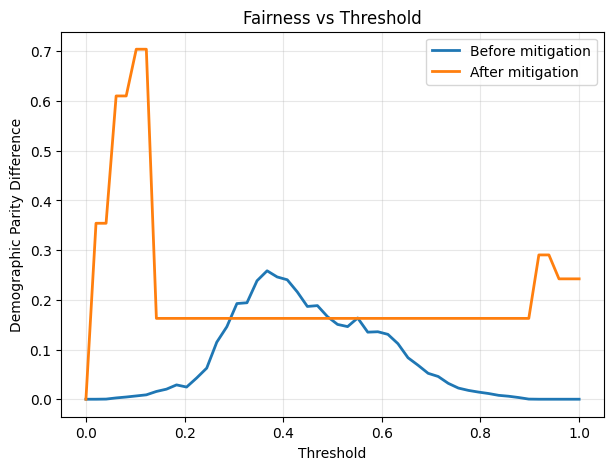

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(thresholds, dp_before, label="Before mitigation", linewidth=2)
plt.plot(thresholds, dp_after, label="After mitigation", linewidth=2)

plt.xlabel("Threshold")
plt.ylabel("Demographic Parity Difference")
plt.title("Fairness vs Threshold")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

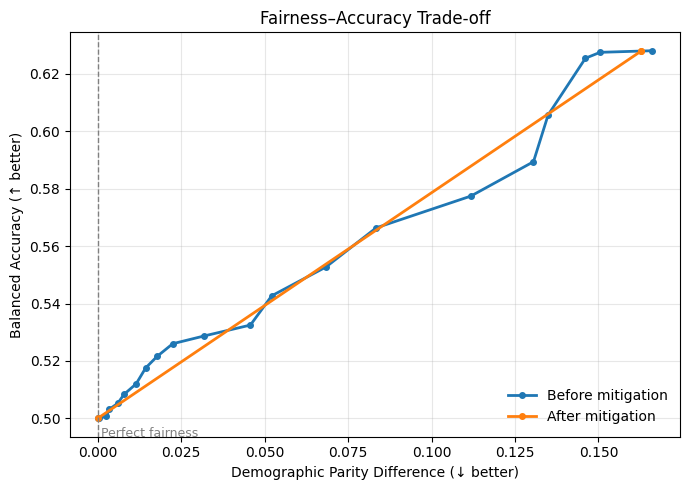

In [ ]:
# Convert to arrays
dp_before = np.array(dp_before)
acc_before = np.array(acc_before)
dp_after = np.array(dp_after)
acc_after = np.array(acc_after)

# Sort by fairness (ascending)
idx_b = np.argsort(dp_before)
idx_a = np.argsort(dp_after)

dp_before, acc_before = dp_before[idx_b], acc_before[idx_b]
dp_after, acc_after = dp_after[idx_a], acc_after[idx_a]

def pareto_frontier(dp, acc):
    frontier_dp = []
    frontier_acc = []
    best_acc = -np.inf

    for d, a in zip(dp, acc):
        if a > best_acc:
            frontier_dp.append(d)
            frontier_acc.append(a)
            best_acc = a

    return np.array(frontier_dp), np.array(frontier_acc)

dp_before_pf, acc_before_pf = pareto_frontier(dp_before, acc_before)
dp_after_pf, acc_after_pf = pareto_frontier(dp_after, acc_after)

plt.figure(figsize=(7,5))

plt.plot(dp_before_pf, acc_before_pf, '-o', label="Before mitigation", linewidth=2, markersize=4)
plt.plot(dp_after_pf, acc_after_pf, '-o', label="After mitigation", linewidth=2, markersize=4)

plt.axvline(0, linestyle="--", color="gray", linewidth=1)
plt.text(0.001, plt.ylim()[0], "Perfect fairness", fontsize=9, color="gray")

plt.xlabel("Demographic Parity Difference (↓ better)")
plt.ylabel("Balanced Accuracy (↑ better)")
plt.title("Fairness–Accuracy Trade-off")

plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
